In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
X = pd.read_csv("X_scaled.csv")

y = pd.read_csv("y.csv").squeeze()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(random_state=42)

In [5]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [6]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [8]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [9]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.8375


In [10]:
best_model = grid_search.best_estimator_

In [11]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8


In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Default)",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [
        rf.fit(X_train, y_train).score(X_test, y_test),
        accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest (Default),0.795
1,Random Forest (Tuned),0.800


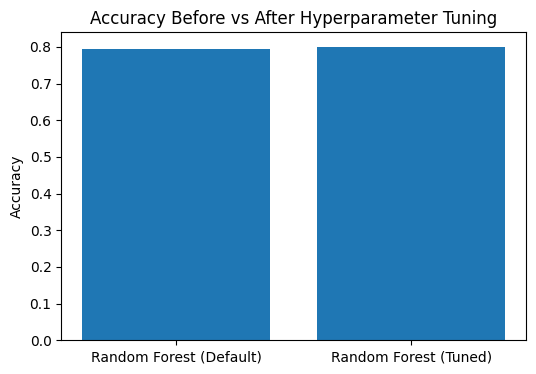

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Before vs After Hyperparameter Tuning")

plt.ylabel("Accuracy")

plt.show()